# 一、环境设置与数据导入

## 1.初步设置

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# 自适应双数据源：本地有完整数据优先使用，无则读取仓库1万条小样
if os.path.exists("data/UserBehavior.csv"):
    df = pd.read_csv("data/UserBehavior.csv", names=["user_id","item_id","category_id","behavior","timestamp"])
    df_sample = df.sample(n=10000, random_state=42)
    print("✅ 加载本地完整原始数据集,抽取1万样本用于分析")
else:
    df_sample = pd.read_csv("data/small_sample.csv")
    print("⚠️ 未检测到完整原始数据,使用仓库内置10000条轻量化样本")

✅ 加载本地完整原始数据集,抽取1万样本用于分析


## 2.了解数据详细

In [11]:
# 前5行数据（完整表格）
print("----- 数据集前5行 -----")
print(df_sample.head())
# 数据类型、缺失值统计
print("---- 数据基本信息 -----")
df_sample.info()
# 数值字段统计（均值、最值、标准差）
print("----- 数值特征统计 -----")
print(df_sample.describe())

----- 数据集前5行 -----
          user_id  item_id  category_id behavior   timestamp
43314727   237858  1062152      1464116       pv  1512212331
88035905    44200  3916487      4135836       pv  1511931558
38200464   920479  2816757       154040       pv  1512311001
83578911   239462  2698818       154040       pv  1511783539
78996463   947273  3991295      1029459       pv  1512273837
---- 数据基本信息 -----
<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 43314727 to 57326995
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      10000 non-null  int64 
 1   item_id      10000 non-null  int64 
 2   category_id  10000 non-null  int64 
 3   behavior     10000 non-null  object
 4   timestamp    10000 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 468.8+ KB
----- 数值特征统计 -----
            user_id       item_id   category_id     timestamp
count  1.000000e+04  1.000000e+04  1.000000e+04  1.000000e+04
me

# 二、数据清洗

## 1.数据类型转换

In [12]:
# 时间戳转标准时间
df_sample["time"] = pd.to_datetime(df_sample["timestamp"], unit="s")
df_sample["date"] = df_sample["time"].dt.date
df_sample["hour"] = df_sample["time"].dt.hour
df_sample["weekday"] = df_sample["time"].dt.dayofweek  # 0周一~6周日
# 标记工作日：0-4工作日，5/6周末
df_sample["is_workday"] = df_sample["weekday"].apply(lambda x: 1 if x < 5 else 0)

## 2.筛选限定范围的数据

In [13]:
# 限定数据集原始时间范围：2017-11-25 ~ 2017-12-03
start = pd.to_datetime("2017-11-25")
end = pd.to_datetime("2017-12-04")
df_sample = df_sample[(df_sample["time"] >= start) & (df_sample["time"] < end)]

## 3.删除重复数据 优化索引

In [19]:
# 删除完全重复的单条行为记录
df_sample = df_sample.drop_duplicates(subset=["user_id","item_id","behavior","timestamp"])
# 重置索引
df_sample = df_sample.reset_index(drop=True)
print("清洗完成，剩余有效数据：", len(df_sample))
df_sample.head()

清洗完成，剩余有效数据： 9891


,user_id,item_id,category_id,behavior,timestamp,time,date,hour,weekday,is_workday
0,237858,1062152,1464116,pv,1512212331,2017-12-02 10:58:51,2017-12-02,10,5,0
1,44200,3916487,4135836,pv,1511931558,2017-11-29 04:59:18,2017-11-29,4,2,1
2,920479,2816757,154040,pv,1512311001,2017-12-03 14:23:21,2017-12-03,14,6,0
3,239462,2698818,154040,pv,1511783539,2017-11-27 11:52:19,2017-11-27,11,0,1
4,947273,3991295,1029459,pv,1512273837,2017-12-03 04:03:57,2017-12-03,4,6,0


In [22]:
# 固定随机种子，生成10000条轻量化样本，用于上传GitHub
df_small = df_sample.sample(n=10000, random_state=42)
df_small.to_csv("data/small_sample.csv", index=False, encoding="utf-8-sig")
print("轻量化1万条样本已导出至 data/small_sample.csv")

轻量化1万条样本已导出至 data/small_sample.csv


# 三、分析计算和可视化

## 1.转化漏斗计算 & 可视化

浏览量PV：8843
加购+收藏总量：853，浏览→加购收藏转化率：9.65%
最终购买量：195，加购收藏→购买转化率：22.86%


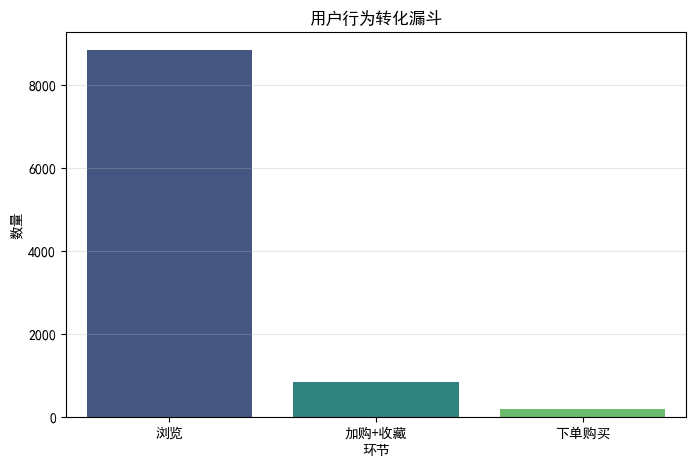

In [15]:
# 统计四种行为数量
behavior_count = df_sample["behavior"].value_counts()
pv = behavior_count["pv"]
cart = behavior_count["cart"]
fav = behavior_count["fav"]
buy = behavior_count["buy"]

# 漏斗层级：浏览 → 加购+收藏 → 购买
step1 = pv
step2 = cart + fav
step3 = buy

print(f"浏览量PV：{step1}")
print(f"加购+收藏总量：{step2}，浏览→加购收藏转化率：{step2/step1:.2%}")
print(f"最终购买量：{step3}，加购收藏→购买转化率：{step3/step2:.2%}")

# 漏斗柱状图
funnel_data = pd.DataFrame({
    "环节":["浏览","加购+收藏","下单购买"],
    "数量":[step1, step2, step3]
})
plt.figure(figsize=(8,5))
sns.barplot(x="环节", y="数量", data=funnel_data, palette="viridis")
plt.title("用户行为转化漏斗")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 2.分时流量分析（工作日 / 周末对比）

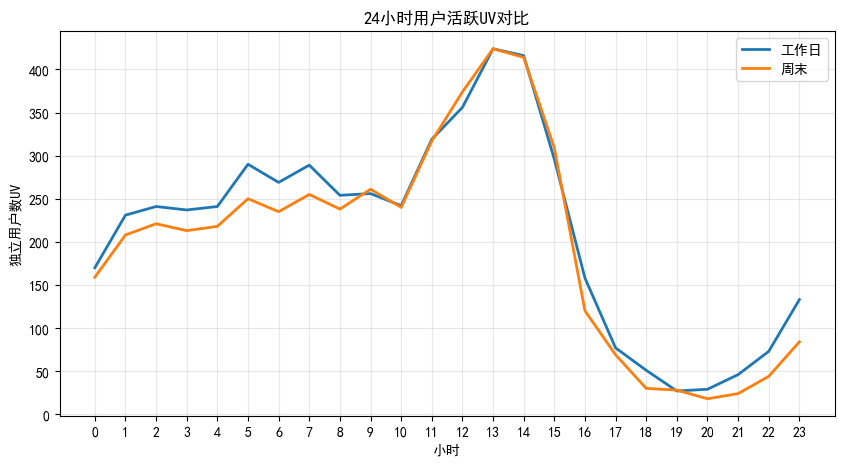

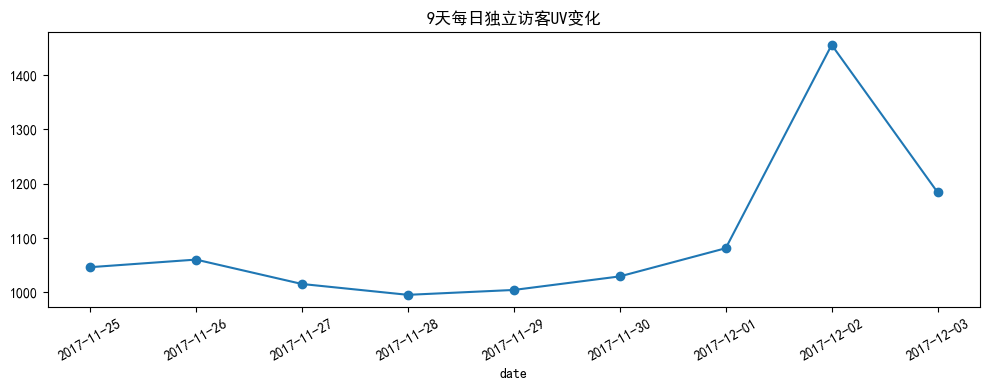

In [16]:
# 按小时+工作日分组求均值
hour_work = df_sample[df_sample["is_workday"]==1].groupby("hour")["user_id"].nunique()
hour_weekend = df_sample[df_sample["is_workday"]==0].groupby("hour")["user_id"].nunique()

plt.figure(figsize=(10,5))
plt.plot(hour_work.index, hour_work.values, label="工作日", linewidth=2)
plt.plot(hour_weekend.index, hour_weekend.values, label="周末", linewidth=2)
plt.title("24小时用户活跃UV对比")
plt.xlabel("小时")
plt.ylabel("独立用户数UV")
plt.legend()
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.show()

# 每日整体UV趋势
daily_uv = df_sample.groupby("date")["user_id"].nunique()
plt.figure(figsize=(10,4))
daily_uv.plot(kind="line", marker="o")
plt.title("9天每日独立访客UV变化")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3.商品类目热度 TOP 分析

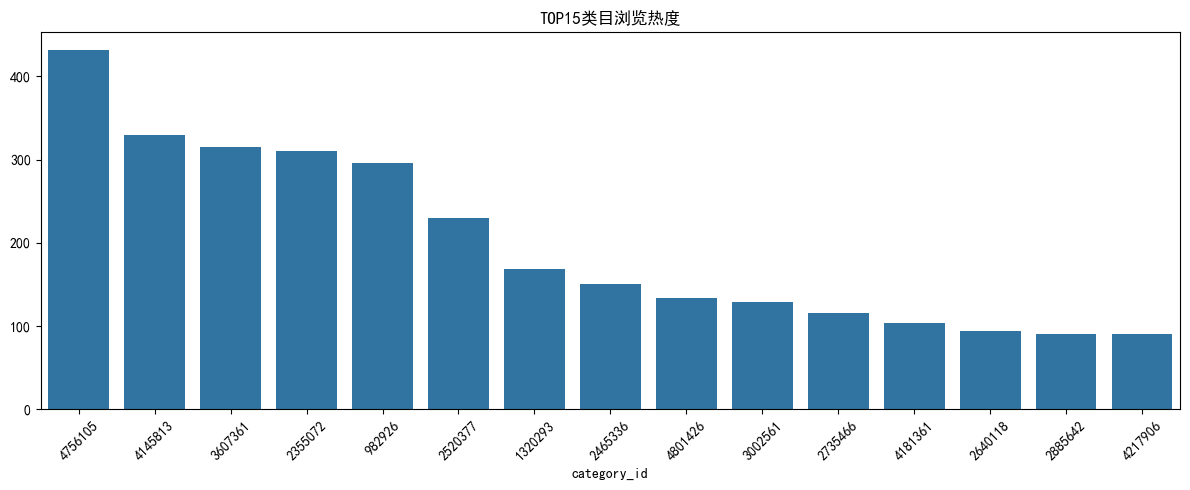

购买量TOP10类目:
 category_id
4145813    4
1464116    4
2735466    4
2939262    3
102272     3
800581     2
4558987    2
570735     2
4173315    2
3776866    2
dtype: int64


In [17]:
# 各类目浏览量排序
cat_pv = df_sample[df_sample["behavior"]=="pv"].groupby("category_id").size().sort_values(ascending=False)
top15_cat = cat_pv.head(15)

plt.figure(figsize=(12,5))
sns.barplot(x=top15_cat.index.astype(str), y=top15_cat.values)
plt.title("TOP15类目浏览热度")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 各类目购买量
cat_buy = df_sample[df_sample["behavior"]=="buy"].groupby("category_id").size().sort_values(ascending=False)
print("购买量TOP10类目:\n", cat_buy.head(10))

# 四、简易 RFM 用户分层模型

In [18]:
# 筛选有过购买行为的用户
buy_df = df_sample[df_sample["behavior"]=="buy"]
# F：购买频次
rfm_F = buy_df.groupby("user_id").size().reset_index(name="F")
# R：最后一次购买距离数据集最后一天的天数
last_day = pd.to_datetime("2017-12-03")
rfm_R = buy_df.groupby("user_id")["time"].max().reset_index()
rfm_R["R"] = (last_day - rfm_R["time"]).dt.days
rfm_R = rfm_R[["user_id","R"]]

# M：用户总互动行为数（浏览+加购+收藏+购买）
rfm_M = df_sample.groupby("user_id").size().reset_index(name="M")

# 合并RFM三张表
rfm = pd.merge(rfm_R, rfm_F, on="user_id", how="outer")
rfm = pd.merge(rfm, rfm_M, on="user_id", how="outer")
rfm = rfm.fillna(0)

# 简单分层规则
def user_level(row):
    if row["R"] <= 2 and row["F"] >= 2:
        return "高价值核心用户"
    elif row["R"] <= 4:
        return "潜力活跃用户"
    elif row["F"] == 0:
        return "浏览新用户"
    else:
        return "沉睡流失用户"

rfm["user_type"] = rfm.apply(user_level, axis=1)
# 统计各类用户数量
print(rfm["user_type"].value_counts())

# 导出清洗后全量数据，用于Tableau导入
df_sample.to_csv("taobao_clean_data.csv", index=False, encoding="utf-8-sig")
rfm.to_csv("taobao_rfm_user.csv", index=False, encoding="utf-8-sig")

user_type
潜力活跃用户    9737
沉睡流失用户      73
Name: count, dtype: int64
